In [15]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score, precision_score, recall_score)

os.makedirs('results', exist_ok=True)
os.makedirs('models', exist_ok=True)

TRAIN_PATH  = os.path.join('data_split', 'train')
VAL_PATH    = os.path.join('data_split', 'val')
TEST_PATH   = os.path.join('data_split', 'test')
IMG_SIZE    = (100, 100)
BATCH_SIZE  = 32
CLASS_NAMES = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

train_datagen    = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_PATH, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True, seed=42
)
val_generator = val_test_datagen.flow_from_directory(
    VAL_PATH, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)
test_generator = val_test_datagen.flow_from_directory(
    TEST_PATH, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)
print("Generators ready!")

Found 11920 images belonging to 6 classes.
Found 2552 images belonging to 6 classes.
Found 2562 images belonging to 6 classes.
Generators ready!


In [16]:
base_model = MobileNetV2(
    input_shape=(100, 100, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

inputs  = tf.keras.Input(shape=(100, 100, 3))
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dense(256, activation='relu')(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.5)(x)
x       = layers.Dense(128, activation='relu')(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(6, activation='softmax')(x)

transfer_model = models.Model(inputs, outputs, name="Transfer_MobileNetV2")
transfer_model.summary()

C:\Users\DELL\AppData\Local\Temp\ipykernel_15712\267505945.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Model: "Transfer_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)           │ (None, 100, 100, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 4, 4, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_2           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 256)                 │         327,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 6)                   │             774 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,620,614 (10.00 MB)

 Trainable params: 362,118 (1.38 MB)

 Non-trainable params: 2,258,496 (8.62 MB)

In [17]:
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

phase1_callbacks = [
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        'models/transfer_phase1_best.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

print("PHASE 1: Training custom head only (base layers frozen)")
phase1_start   = time.time()
history_phase1 = transfer_model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    callbacks=phase1_callbacks,
    verbose=1
)
phase1_time = time.time() - phase1_start
print(f"Phase 1 finished in {phase1_time/60:.1f} minutes")

PHASE 1: Training custom head only (base layers frozen)
Epoch 1/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.4380 - loss: 1.7568
Epoch 1: val_loss improved from None to 0.52042, saving model to models/transfer_phase1_best.keras

Epoch 1: finished saving model to models/transfer_phase1_best.keras
373/373 ━━━━━━━━━━━━━━━━━━━━ 92s 234ms/step - accuracy: 0.5709 - loss: 1.2823 - val_accuracy: 0.8194 - val_loss: 0.5204
Epoch 2/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.7244 - loss: 0.7997
Epoch 2: val_loss improved from 0.52042 to 0.45992, saving model to models/transfer_phase1_best.keras

Epoch 2: finished saving model to models/transfer_phase1_best.keras
373/373 ━━━━━━━━━━━━━━━━━━━━ 87s 234ms/step - accuracy: 0.7348 - loss: 0.7666 - val_accuracy: 0.8307 - val_loss: 0.4599
Epoch 3/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - accuracy: 0.7542 - loss: 0.6876
Epoch 3: val_loss improved from 0.45992 to 0.42045, saving model to models/transfer_phase1_best.keras

In [18]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

print(f"Unfrozen base layers: {sum(1 for l in base_model.layers if l.trainable)}")

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

transfer_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=7,
                            restore_best_weights=True, verbose=1),
    callbacks.ModelCheckpoint('models/transfer_best.keras', monitor='val_accuracy',
                              save_best_only=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=3, verbose=1, min_lr=1e-8)
]

print("\nPHASE 2: Fine-tuning")
phase2_start = time.time()
history_transfer = transfer_model.fit(
    train_generator, epochs=25,
    validation_data=val_generator,
    callbacks=transfer_callbacks, verbose=1
)
phase2_time = time.time() - phase2_start       
transfer_time = phase1_time + phase2_time      
print(f"\nTraining finished in {transfer_time/60:.1f} minutes")

Unfrozen base layers: 30

PHASE 2: Fine-tuning
Epoch 1/25
373/373 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - accuracy: 0.7671 - loss: 0.6491
Epoch 1: val_accuracy improved from None to 0.88127, saving model to models/transfer_best.keras

Epoch 1: finished saving model to models/transfer_best.keras
373/373 ━━━━━━━━━━━━━━━━━━━━ 119s 294ms/step - accuracy: 0.7931 - loss: 0.5789 - val_accuracy: 0.8813 - val_loss: 0.4130 - learning_rate: 1.0000e-04
Epoch 2/25
373/373 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - accuracy: 0.8382 - loss: 0.4527
Epoch 2: val_accuracy did not improve from 0.88127
373/373 ━━━━━━━━━━━━━━━━━━━━ 107s 287ms/step - accuracy: 0.8413 - loss: 0.4491 - val_accuracy: 0.8648 - val_loss: 0.3960 - learning_rate: 1.0000e-04
Epoch 3/25
373/373 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accuracy: 0.8470 - loss: 0.4123
Epoch 3: val_accuracy improved from 0.88127 to 0.88715, saving model to models/transfer_best.keras

Epoch 3: finished saving model to models/transfer_best.keras
373/373 ━━━━━━━━━━━━━

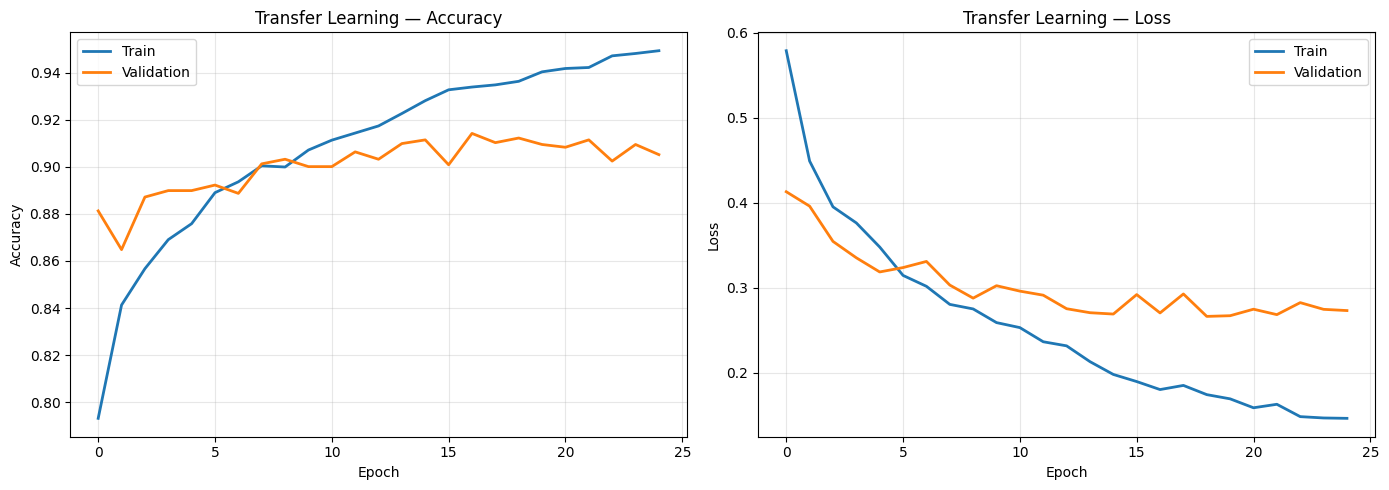

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_transfer.history['accuracy'],     label='Train', linewidth=2)
ax1.plot(history_transfer.history['val_accuracy'], label='Validation', linewidth=2)
ax1.set_title('Transfer Learning — Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history_transfer.history['loss'],     label='Train', linewidth=2)
ax2.plot(history_transfer.history['val_loss'], label='Validation', linewidth=2)
ax2.set_title('Transfer Learning — Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/transfer_curves.png', dpi=150)
plt.show()

81/81 ━━━━━━━━━━━━━━━━━━━━ 19s 204ms/step
TRANSFER LEARNING — Classification Report
              precision    recall  f1-score   support

   buildings       0.89      0.96      0.93       395
      forest       0.99      0.98      0.99       413
     glacier       0.86      0.82      0.84       445
    mountain       0.85      0.87      0.86       457
         sea       0.93      0.94      0.93       419
      street       0.95      0.92      0.93       433

    accuracy                           0.91      2562
   macro avg       0.91      0.91      0.91      2562
weighted avg       0.91      0.91      0.91      2562



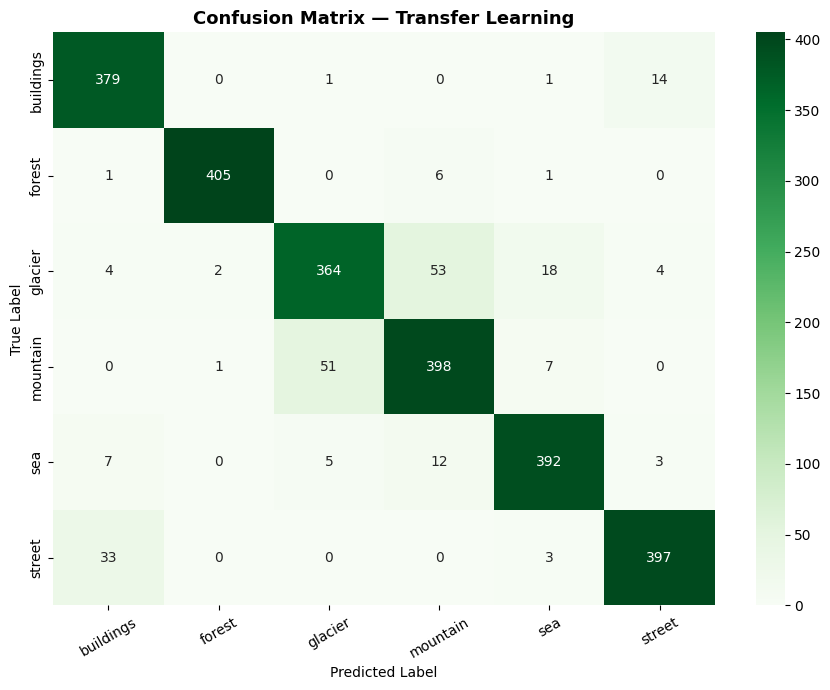

In [20]:
test_generator.reset()
transfer_preds = np.argmax(transfer_model.predict(test_generator, verbose=1), axis=1)
y_true = test_generator.classes

print("TRANSFER LEARNING — Classification Report")
print(classification_report(y_true, transfer_preds, target_names=CLASS_NAMES))

cm = confusion_matrix(y_true, transfer_preds)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix — Transfer Learning', fontsize=13, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('results/transfer_confusion_matrix.png', dpi=150)
plt.show()

In [ ]:
import json

scratch_preds  = np.load('results/scratch_preds.npy')
scratch_time   = np.load('results/scratch_time.npy')[0]
scratch_params = np.load('results/scratch_params.npy')[0]
scratch_model  = tf.keras.models.load_model('models/scratch_best.keras')

with open('results/scratch_history.json', 'r') as f:
    scratch_history = json.load(f)

best_epoch_scratch   = int(np.argmax(scratch_history['val_accuracy']))
scratch_train_acc    = scratch_history['accuracy'][best_epoch_scratch]
scratch_val_acc      = scratch_history['val_accuracy'][best_epoch_scratch]

best_epoch_transfer  = int(np.argmax(history_transfer.history['val_accuracy']))
transfer_train_acc   = history_transfer.history['accuracy'][best_epoch_transfer]
transfer_val_acc     = history_transfer.history['val_accuracy'][best_epoch_transfer]

s = {
    'Accuracy' : accuracy_score(y_true, scratch_preds),
    'Precision': precision_score(y_true, scratch_preds, average='weighted'),
    'Recall'   : recall_score(y_true, scratch_preds, average='weighted'),
    'F1-Score' : f1_score(y_true, scratch_preds, average='weighted'),
}
t = {
    'Accuracy' : accuracy_score(y_true, transfer_preds),
    'Precision': precision_score(y_true, transfer_preds, average='weighted'),
    'Recall'   : recall_score(y_true, transfer_preds, average='weighted'),
    'F1-Score' : f1_score(y_true, transfer_preds, average='weighted'),
}

transfer_params = transfer_model.count_params()

print("=" * 66)
print(f"{'Metric':<26} {'Scratch CNN':>18} {'Transfer MobileNetV2':>18}")
print("=" * 66)
print(f"{'Train Accuracy (best epoch)':<26} {scratch_train_acc:>18.4f} {transfer_train_acc:>18.4f}")
print(f"{'Val Accuracy (best epoch)':<26} {scratch_val_acc:>18.4f} {transfer_val_acc:>18.4f}")
print("-" * 66)
for metric in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    print(f"{'Test ' + metric:<26} {s[metric]:>18.4f} {t[metric]:>18.4f}")
print("-" * 66)
print(f"{'Training Time (min)':<26} {scratch_time/60:>18.1f} {transfer_time/60:>18.1f}")
print(f"{'Total Parameters':<26} {int(scratch_params):>18,} {int(transfer_params):>18,}")
print("=" * 66)

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

test_generator.reset()
scratch_probs  = scratch_model.predict(test_generator, verbose=0)

test_generator.reset()
transfer_probs = transfer_model.predict(test_generator, verbose=0)

y_true_bin = label_binarize(y_true, classes=list(range(len(CLASS_NAMES))))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, probs, title in zip(
    axes,
    [scratch_probs, transfer_probs],
    ['CNN from Scratch', 'Transfer Learning (MobileNetV2)']
):
    for i, cls in enumerate(CLASS_NAMES):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], probs[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, linewidth=1.5, label=f'{cls} (AUC = {roc_auc:.2f})')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
    ax.set_title(f'ROC Curve — {title}', fontsize=12, fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/roc_curves.png', dpi=150)
plt.show()
print("ROC curves saved!")

Metric                            Scratch CNN Transfer MobileNetV2
Train Accuracy (best epoch)             0.8543             0.9339
Val Accuracy (best epoch)              0.8421             0.9142
------------------------------------------------------------------
Test Accuracy                          0.8345             0.9114
Test Precision                         0.8399             0.9118
Test Recall                            0.8345             0.9114
Test F1-Score                          0.8323             0.9112
------------------------------------------------------------------
Training Time (min)                     136.0               61.4
Total Parameters                    5,436,966          2,620,614
